### import libraries

In [23]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil


notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

In [24]:
tpad = 1000
xpad = 64
ypad = 64

### Spectrum for regular SASE pulse

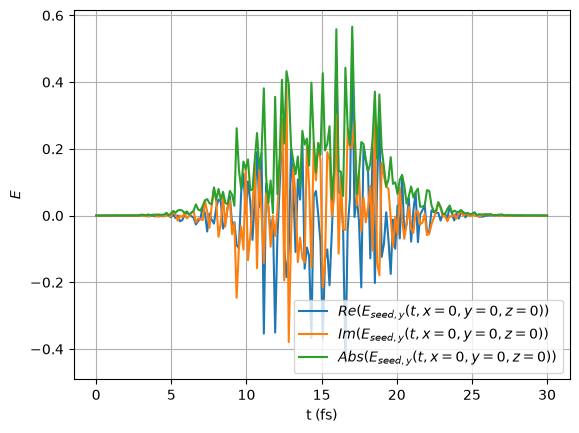

In [25]:
X = XLO_sim(base_directory + '/config/base/Cu-seed-SASE.yaml')
X.random_seed = 42
seed_field = tools.Ocelot_SASE_seed_pstxy(X)
X.configure(seed_field)
X.run_3D()

Omega_pstxy = tools.circular_to_linear(X, X.Omega_pstxyz[:,:,:,:,:,0])
Omega_t   = Omega_pstxy[0,1,:,int(X.xgrid/2),int(X.ygrid/2)]

plt.plot(X.t, np.real(Omega_t), label = r'$Re(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(X.t, np.imag(Omega_t), label = r'$Im(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(X.t, np.abs(Omega_t), label = r'$Abs(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.xlabel('t (fs)')
plt.ylabel(r'$E$')
plt.grid(True)
plt.legend()
plt.show()

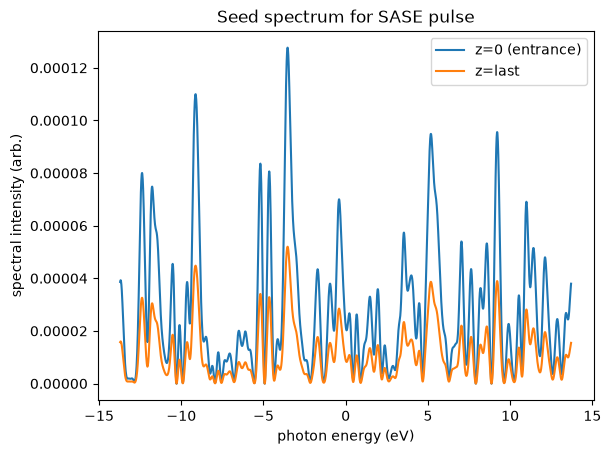

In [26]:
womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

plt.figure()
plt.plot(womega_ar, I_int_thy_w_0, label='z=0 (entrance)')
plt.plot(womega_ar, I_int_thy_w_last, label='z=last')
# plt.axvline(X.hwKalpha1N, color='gray', ls='--', lw=1, label=f'Cu K$\\alpha$1 = {X.hwKalpha1N:.2f} eV')
plt.xlabel('photon energy (eV)')
plt.ylabel('spectral intensity (arb.)')
plt.legend()
plt.title('Seed spectrum for SASE pulse')
plt.show()

### Spectrum for monochromated SASE pulse

8040
8040


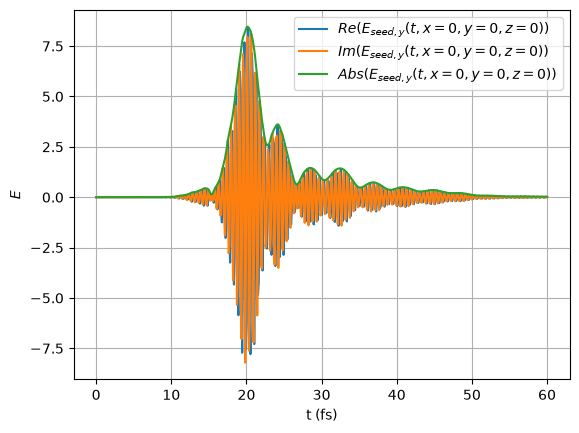

In [27]:
X = XLO_sim(base_directory + '/config/base/Cu-seed-mono-SASE.yaml')
X.seed_delay = -10
X.random_seed = 42
X.monochromator_target_energy_eV = 8040
seed_field = tools.Ocelot_SASE_seed_111_dcm_pstxy(X)
X.configure(seed_field)
X.run_3D()

Omega_pstxy = tools.circular_to_linear(X, X.Omega_pstxyz[:,:,:,:,:,0])
Omega_t   = Omega_pstxy[0,1,:,int(X.xgrid/2),int(X.ygrid/2)]

plt.plot(X.t, np.real(Omega_t), label = r'$Re(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(X.t, np.imag(Omega_t), label = r'$Im(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(X.t, np.abs(Omega_t), label = r'$Abs(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.xlabel('t (fs)')
plt.ylabel(r'$E$')
plt.grid(True)
plt.legend()
plt.show()

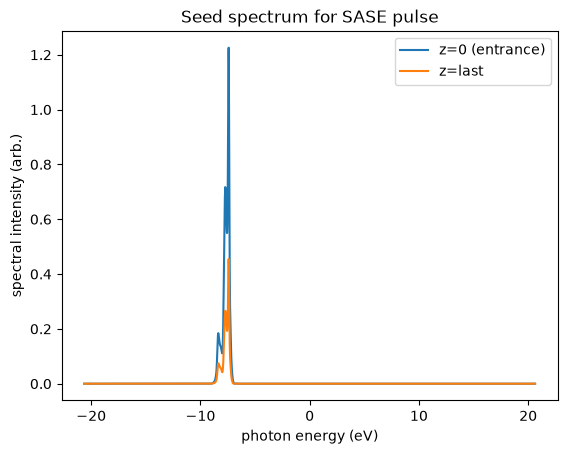

In [28]:
womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

plt.figure()
plt.plot(womega_ar, I_int_thy_w_0, label='z=0 (entrance)')
plt.plot(womega_ar, I_int_thy_w_last, label='z=last')
plt.xlabel('photon energy (eV)')
plt.ylabel('spectral intensity (arb.)')
plt.legend()
plt.title('Seed spectrum for SASE pulse')
plt.show()